In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [58]:
# ==========================================================
# Install Packages
# ==========================================================

!pip -q install lime
!pip -q install opencv-python
!pip -q install scikit-image
!pip -q install seaborn

In [60]:
# ==========================================================
# Import Libraries
# ==========================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    average_precision_score,
    precision_recall_curve
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [61]:
# ==========================================================
# Reproducibility
# ==========================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

In [62]:
# ==========================================================
# Kaggle Dataset Path
# ==========================================================

KAGGLE_INPUT = "/kaggle/input/datasets/mohitsingh1804/plantvillage"

for root, dirs, files in os.walk(KAGGLE_INPUT):

    if len(dirs) > 0:

        print(root)

/kaggle/input/datasets/mohitsingh1804/plantvillage
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train


In [66]:
# ==========================================================
# Automatically Find PlantVillage Dataset
# ==========================================================

import os

BASE_PATH = "/kaggle/input/datasets/mohitsingh1804/plantvillage"

DATASET_PATH = None

for root, dirs, files in os.walk(BASE_PATH):

    # Check if this directory contains class folders
    if len(dirs) >= 38:

        DATASET_PATH = root
        break

if DATASET_PATH is None:
    raise Exception("PlantVillage folder not found!")

print("Dataset Path:")
print(DATASET_PATH)

Dataset Path:
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val


In [67]:
# ==========================================================
# Verify Dataset
# ==========================================================

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print("Total Classes:", len(classes))
print(classes)

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

In [68]:
# ==========================================================
# Dataset Distribution
# ==========================================================

import pandas as pd

counts = []

for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    num = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    counts.append(num)

df = pd.DataFrame({
    "Class": classes,
    "Images": counts
})

display(df)

,Class,Images
0,Apple___Apple_scab,126
1,Apple___Black_rot,125
2,Apple___Cedar_apple_rust,55
3,Apple___healthy,329
4,Blueberry___healthy,300
5,Cherry_(including_sour)___Powdery_mildew,210
6,Cherry_(including_sour)___healthy,170
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,103
8,Corn_(maize)___Common_rust_,239
9,Corn_(maize)___Northern_Leaf_Blight,197


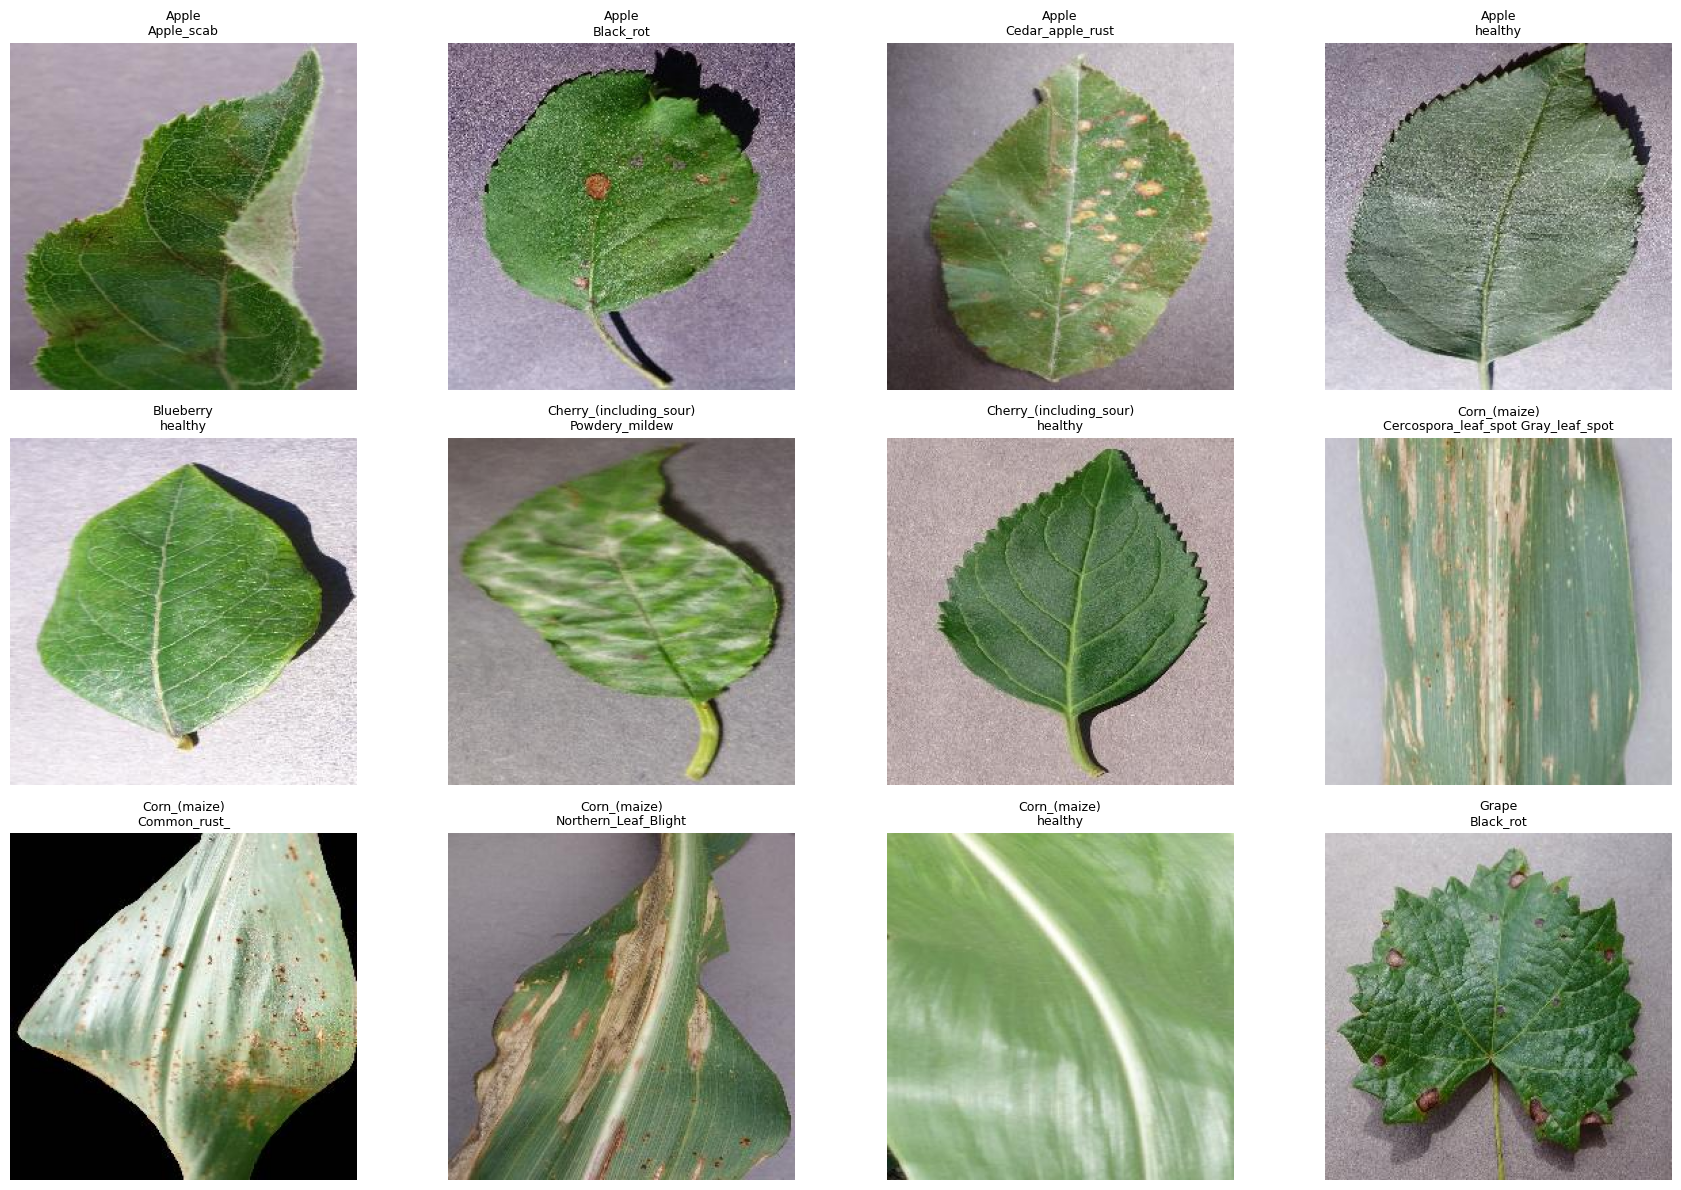

In [69]:
# ==========================================================
# Show Sample Images
# ==========================================================

import cv2
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))

for i, cls in enumerate(classes[:12]):

    folder = os.path.join(DATASET_PATH, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    img_name = random.choice(images)

    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)

    plt.imshow(img)

    plt.title(cls.replace("___","\n"), fontsize=9)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [70]:
# ==========================================================
# Dataset Libraries
# ==========================================================

import cv2
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [71]:
# ==========================================================
# Configuration
# ==========================================================

IMAGE_SIZE = 224

BATCH_SIZE = 32

RANDOM_STATE = 42

In [72]:
# ==========================================================
# Automatic Leaf Segmentation
# ==========================================================

def segment_leaf(image):

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower_green = np.array([25, 30, 30])

    upper_green = np.array([100, 255, 255])

    mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    kernel = np.ones((5,5), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    segmented = cv2.bitwise_and(
        image,
        image,
        mask=mask
    )

    return segmented

In [73]:
# ==========================================================
# Read Dataset
# ==========================================================

images = []

labels = []

image_extensions = (".jpg", ".jpeg", ".png")

for cls in tqdm(classes):

    folder = os.path.join(DATASET_PATH, cls)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    ]

    for file in files:

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = segment_leaf(img)

        img = cv2.resize(
            img,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        images.append(img)

        labels.append(cls)

images = np.array(images)

labels = np.array(labels)

print(images.shape)

print(labels.shape)

100%|██████████| 38/38 [00:31<00:00,  1.21it/s]


(10861, 224, 224, 3)
(10861,)


In [74]:
# ==========================================================
# MobileNetV2 Preprocessing
# ==========================================================

images = tf.keras.applications.mobilenet_v2.preprocess_input(images)

In [84]:
# ===========================
# PART: Train-Test Split
# ===========================

import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Dataset Path
# ---------------------------
DATASET_DIR = "/kaggle/input/datasets/mohitsingh1804/plantvillage"

# Automatically find the folder containing class directories
for root, dirs, files in os.walk(DATASET_DIR):
    if len(dirs) >= 38:
        DATASET_DIR = root
        break

print("Dataset Directory:", DATASET_DIR)

# ---------------------------
# Read Image Paths & Labels
# ---------------------------
image_paths = []
labels = []

class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

print(f"Number of Classes Found: {len(class_names)}")

for class_name in class_names:

    class_dir = os.path.join(DATASET_DIR, class_name)

    for file in os.listdir(class_dir):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_paths.append(os.path.join(class_dir, file))
            labels.append(class_name)

# Convert to NumPy arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total Images:", len(image_paths))

# ---------------------------
# Encode Labels
# ---------------------------
encoder = LabelEncoder()

labels = encoder.fit_transform(labels)

print("Encoded Labels Shape:", labels.shape)
print("Total Classes:", len(encoder.classes_))

# ---------------------------
# 80:20 Stratified Split
# ---------------------------
RANDOM_STATE = 42

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=labels
)

# ---------------------------
# Results
# ---------------------------
print("=" * 40)
print("Training Images :", len(train_paths))
print("Testing Images  :", len(test_paths))
print("Training Labels :", train_labels.shape)
print("Testing Labels  :", test_labels.shape)
print("=" * 40)

Dataset Directory: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val
Number of Classes Found: 38
Total Images: 10861
Encoded Labels Shape: (10861,)
Total Classes: 38
Training Images : 8688
Testing Images  : 2173
Training Labels : (8688,)
Testing Labels  : (2173,)


In [85]:
# ==========================================================
# Data Augmentation
# ==========================================================

train_datagen = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode="nearest"

)

test_datagen = ImageDataGenerator()

In [87]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(encoder.classes_)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (
    train_ds
    .shuffle(len(train_paths))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(train_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>


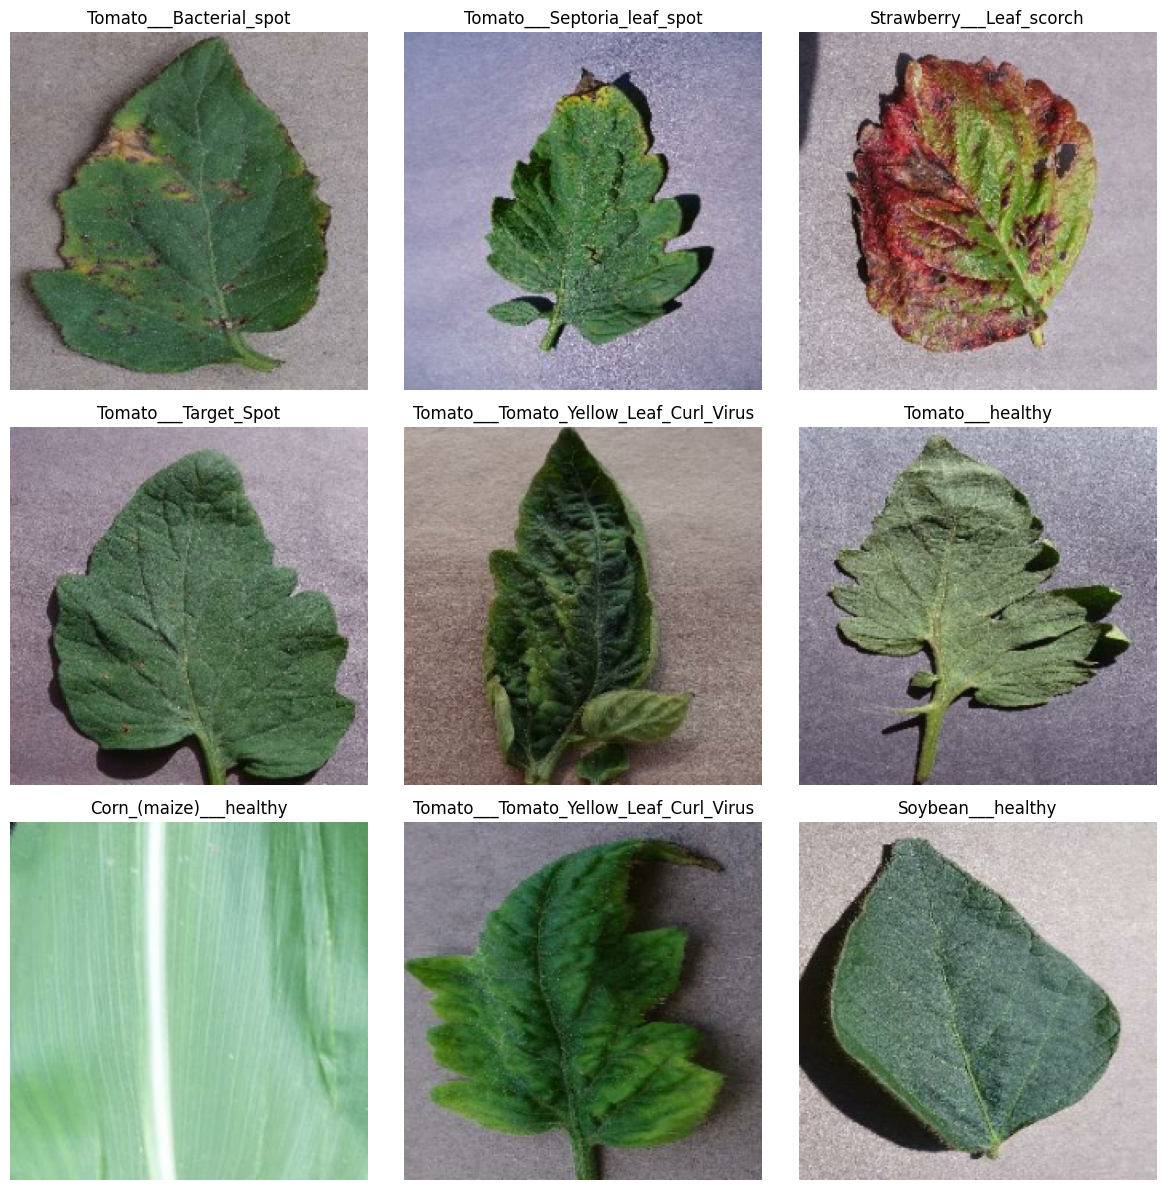

In [89]:
import matplotlib.pyplot as plt
import numpy as np

class_names = encoder.classes_

plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy())

        plt.title(class_names[np.argmax(labels[i].numpy())])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [90]:
# ==========================================================
# ConViTX Configuration
# ==========================================================

IMAGE_SIZE = 224

PATCH_SIZE = 7

NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

PROJECTION_DIM = 48

NUM_HEADS = 4

TRANSFORMER_LAYERS = 8

TRANSFORMER_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM
]

In [104]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow:", tf.__version__)

IMG_SIZE = 224

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Model Loaded Successfully")

TensorFlow: 2.20.0


Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5: None -- [Errno -3] Temporary failure in name resolution

In [105]:
# ==========================================================
# MLP
# ==========================================================

def mlp(x,
        hidden_units,
        dropout_rate):

    for units in hidden_units:

        x = layers.Dense(
            units,
            activation=tf.nn.gelu
        )(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

    return x

In [96]:
# ==========================================================
# Patch Layer
# ==========================================================

class Patches(layers.Layer):

    def __init__(self,
                 patch_size):

        super().__init__()

        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(

            images=images,

            sizes=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            strides=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            rates=[1,1,1,1],

            padding="VALID"

        )

        patch_dim = patches.shape[-1]

        patches = tf.reshape(

            patches,

            [

                batch_size,

                -1,

                patch_dim

            ]

        )

        return patches

    def get_config(self):

        return {

            "patch_size": self.patch_size

        }

In [97]:
# ==========================================================
# Patch Encoder
# ==========================================================

class PatchEncoder(layers.Layer):

    def __init__(self,
                 num_patches,
                 projection_dim):

        super().__init__()

        self.num_patches = num_patches

        self.projection_dim = projection_dim

        self.projection = layers.Dense(
            projection_dim
        )

        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self,
             patch):

        positions = tf.range(

            start=0,

            limit=self.num_patches,

            delta=1

        )

        encoded = self.projection(

            patch

        ) + self.position_embedding(

            positions

        )

        return encoded

    def get_config(self):

        return {

            "num_patches": self.num_patches,

            "projection_dim": self.projection_dim

        }

In [106]:
# ==========================================================
# Squeeze Excitation
# ==========================================================

def se_block(x,
             ratio=4):

    filters = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Reshape(
        (1,1,filters)
    )(se)

    se = layers.Dense(
        filters//ratio,
        activation="relu"
    )(se)

    se = layers.Dense(
        filters,
        activation="sigmoid"
    )(se)

    return layers.Multiply()([x,se])

In [107]:
# ==========================================================
# CNN Feature Extraction
# ==========================================================

cnn_features = base_model.get_layer(

    "block_6_project_BN"

).output

cnn_features = se_block(
    cnn_features
)

print(cnn_features.shape)

(None, 14, 14, 64)


In [108]:
# ==========================================================
# Vision Transformer Input
# ==========================================================

patches = Patches(
    PATCH_SIZE
)(base_model.input)

encoded_patches = PatchEncoder(
    NUM_PATCHES,
    PROJECTION_DIM
)(patches)

print(encoded_patches.shape)

(None, 1024, 48)


In [109]:
# ==========================================================
# Transformer
# ==========================================================

x = encoded_patches

for _ in range(TRANSFORMER_LAYERS):

    x1 = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    attention = layers.MultiHeadAttention(

        num_heads=NUM_HEADS,

        key_dim=PROJECTION_DIM,

        dropout=0.1

    )(x1,x1)

    x2 = layers.Add()([attention,x])

    x3 = layers.LayerNormalization(
        epsilon=1e-6
    )(x2)

    x3 = mlp(

        x3,

        TRANSFORMER_UNITS,

        0.1

    )

    x = layers.Add()([x3,x2])

vit_features = layers.LayerNormalization(
    epsilon=1e-6
)(x)

In [110]:
# ==========================================================
# Feature Map
# ==========================================================

vit_features = layers.Reshape(

    (32,32,48)

)(vit_features)

vit_features = layers.DepthwiseConv2D(

    3,

    padding="same",

    activation="relu"

)(vit_features)

vit_features = layers.DepthwiseConv2D(

    3,

    padding="same",

    activation="relu"

)(vit_features)

vit_features = layers.DepthwiseConv2D(

    3,

    strides=2,

    padding="same",

    activation="relu"

)(vit_features)

vit_features = layers.Resizing(
    14,
    14
)(vit_features)

vit_features = se_block(
    vit_features
)

In [111]:
# ==========================================================
# Feature Fusion
# ==========================================================

fusion = layers.Concatenate(
    name="cam_layer1"
)([cnn_features,vit_features])

fusion = layers.Conv2D(

    128,

    3,

    padding="same",

    activation="relu"

)(fusion)

fusion = layers.BatchNormalization()(fusion)

fusion = se_block(fusion)

In [112]:
# ==========================================================
# Output Layer
# ==========================================================

gap = layers.GlobalAveragePooling2D()(fusion)

drop = layers.Dropout(0.30)(gap)

output = layers.Dense(

    NUM_CLASSES,

    activation="softmax"

)(drop)

model = tf.keras.Model(

    inputs=base_model.input,

    outputs=output,

    name="ConViTX"

)

model.summary()

Model: "ConViTX"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 147) │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 1024, 48)  │     56,256 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1024, 48)  │         96 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 48)  │     37,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 48)  │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 48)  │         96 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024, 96)  │      4,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024, 96)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1024, 48)  │      4,656 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1024, 48)  │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024, 48)  │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 48)  │         96 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 48)  │     37,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1024, 48)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 48)  │         96 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1024, 96)  │      4,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1024, 96)  │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024, 48)  │      4,656 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 661,330 (2.52 MB)

 Trainable params: 656,658 (2.50 MB)

 Non-trainable params: 4,672 (18.25 KB)

In [113]:
# ==========================================================
# Check Model
# ==========================================================

print(model.input_shape)
print(model.output_shape)

model.summary()

(None, 224, 224, 3)
(None, 38)


Model: "ConViTX"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 147) │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 1024, 48)  │     56,256 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1024, 48)  │         96 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 48)  │     37,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 48)  │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 48)  │         96 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024, 96)  │      4,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024, 96)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1024, 48)  │      4,656 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1024, 48)  │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024, 48)  │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 48)  │         96 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 48)  │     37,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1024, 48)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 48)  │         96 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1024, 96)  │      4,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1024, 96)  │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024, 48)  │      4,656 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 661,330 (2.52 MB)

 Trainable params: 656,658 (2.50 MB)

 Non-trainable params: 4,672 (18.25 KB)

In [114]:
# ==========================================================
# Learning Rate Scheduler
# ==========================================================

initial_lr = 1e-4

def lr_scheduler(epoch, lr):

    if epoch < 20:
        return initial_lr

    elif epoch < 60:
        return initial_lr * 0.5

    elif epoch < 100:
        return initial_lr * 0.1

    elif epoch < 150:
        return initial_lr * 0.05

    else:
        return initial_lr * 0.01

lr_callback = tf.keras.callbacks.LearningRateScheduler(
    lr_scheduler,
    verbose=1
)

In [115]:
# ==========================================================
# Optimizer
# ==========================================================

optimizer = tf.keras.optimizers.Adam(

    learning_rate=initial_lr

)

In [116]:
# ==========================================================
# Compile
# ==========================================================

model.compile(

    optimizer=optimizer,

    loss="categorical_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall")

    ]

)

In [119]:
# ==========================================================
# Model Checkpoint
# ==========================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "ConViTX_PlantVillage.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1

)

In [ ]:
# ==========================================================
# CSV Logger
# ==========================================================

csv_logger = tf.keras.callbacks.CSVLogger(

    "training_log.csv",

    append=False
)

In [130]:
# ==========================================================
# Compile Model
# ==========================================================

import tensorflow as tf

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ==========================================================
# Callbacks
# ==========================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        "history.csv"
    )

]

# ==========================================================
# Train Model
# ==========================================================

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.7659 - loss: 0.8457 - precision: 0.9135 - recall: 0.6054
Epoch 1: val_accuracy improved from None to 0.10769, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 347s 984ms/step - accuracy: 0.7701 - loss: 0.8269 - precision: 0.9119 - recall: 0.6169 - val_accuracy: 0.1077 - val_loss: 4.7091 - val_precision: 0.1342 - val_recall: 0.0819 - learning_rate: 1.0000e-04
Epoch 2/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.7973 - loss: 0.7450 - precision: 0.9172 - recall: 0.6481
Epoch 2: val_accuracy did not improve from 0.10769
272/272 ━━━━━━━━━━━━━━━━━━━━ 211s 777ms/step - accuracy: 0.7955 - loss: 0.7392 - precision: 0.9197 - recall: 0.6548 - val_accuracy: 0.1008 - val_loss: 5.1019 - val_precision: 0.1259 - val_recall: 0.0861 - learning_rate: 1.0000e-04
Epoch 3/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.8121 - loss: 0.6814 - precision: 0

In [131]:
# ==========================================================
# Save Model
# ==========================================================

model.save(

    "ConViTX_Final.keras"

)

print("Model Saved")

Model Saved


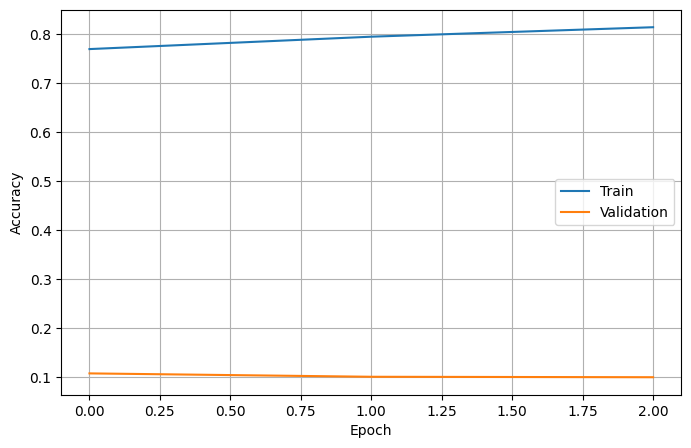

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

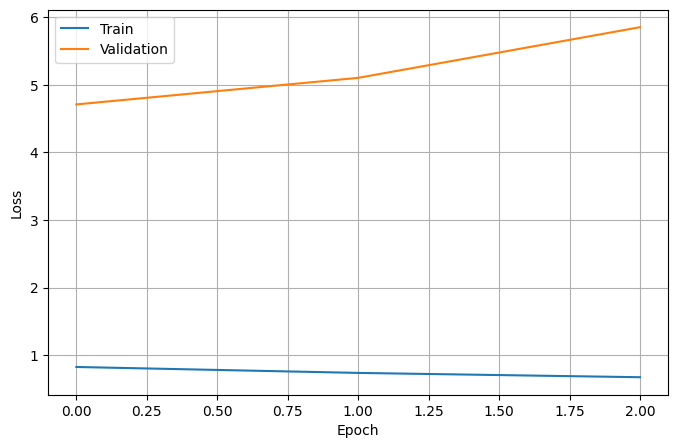

In [134]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [140]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    validation_split=0.20,
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

test_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print(train_generator.samples)
print(test_generator.samples)
pred_prob = model.predict(test_generator)

y_pred = np.argmax(pred_prob, axis=1)

y_true = test_generator.classes

Found 8701 images belonging to 38 classes.
Found 2160 images belonging to 38 classes.
8701
2160
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 377ms/step


In [141]:
# ==========================================================
# Accuracy
# ==========================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(

    y_true,

    y_pred

)

print("Accuracy :",accuracy)

Accuracy : 0.04398148148148148


In [145]:
# ==========================================================
# Precision Recall F1
# ==========================================================

from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score

)

precision = precision_score(

    y_true,

    y_pred,

    average="weighted"

)

recall = recall_score(

    y_true,

    y_pred,

    average="weighted"

)

f1 = f1_score(

    y_true,

    y_pred,

    average="weighted"

)

print()

print("Precision :",precision)

print("Recall :",recall)

print("F1 Score :",f1)


Precision : 0.009732483743879661
Recall : 0.04398148148148148
F1 Score : 0.009641626868135085


In [150]:
from sklearn.metrics import average_precision_score
from tensorflow.keras.utils import to_categorical
import numpy as np

# True labels from generator
y_true = test_generator.classes

# Convert to one-hot encoding
y_true_onehot = to_categorical(
    y_true,
    num_classes=test_generator.num_classes
)

# Calculate mAP
mAP = average_precision_score(
    y_true_onehot,
    pred_prob,
    average="macro"
)

print(f"mAP: {mAP:.4f}")

mAP: 0.0478


In [151]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(

classification_report(

    y_true,

    y_pred,

    target_names=classes,

    digits=4

)

)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.0000    0.0000    0.0000        25
                                 Apple___Black_rot     0.0000    0.0000    0.0000        25
                          Apple___Cedar_apple_rust     0.0000    0.0000    0.0000        11
                                   Apple___healthy     0.0000    0.0000    0.0000        65
                               Blueberry___healthy     0.0000    0.0000    0.0000        60
          Cherry_(including_sour)___Powdery_mildew     0.0000    0.0000    0.0000        42
                 Cherry_(including_sour)___healthy     0.0000    0.0000    0.0000        34
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.0000    0.0000    0.0000        20
                       Corn_(maize)___Common_rust_     0.0000    0.0000    0.0000        47
               Corn_(maize)___Northern_Leaf_Blight     0.0000    0.0000    0.00

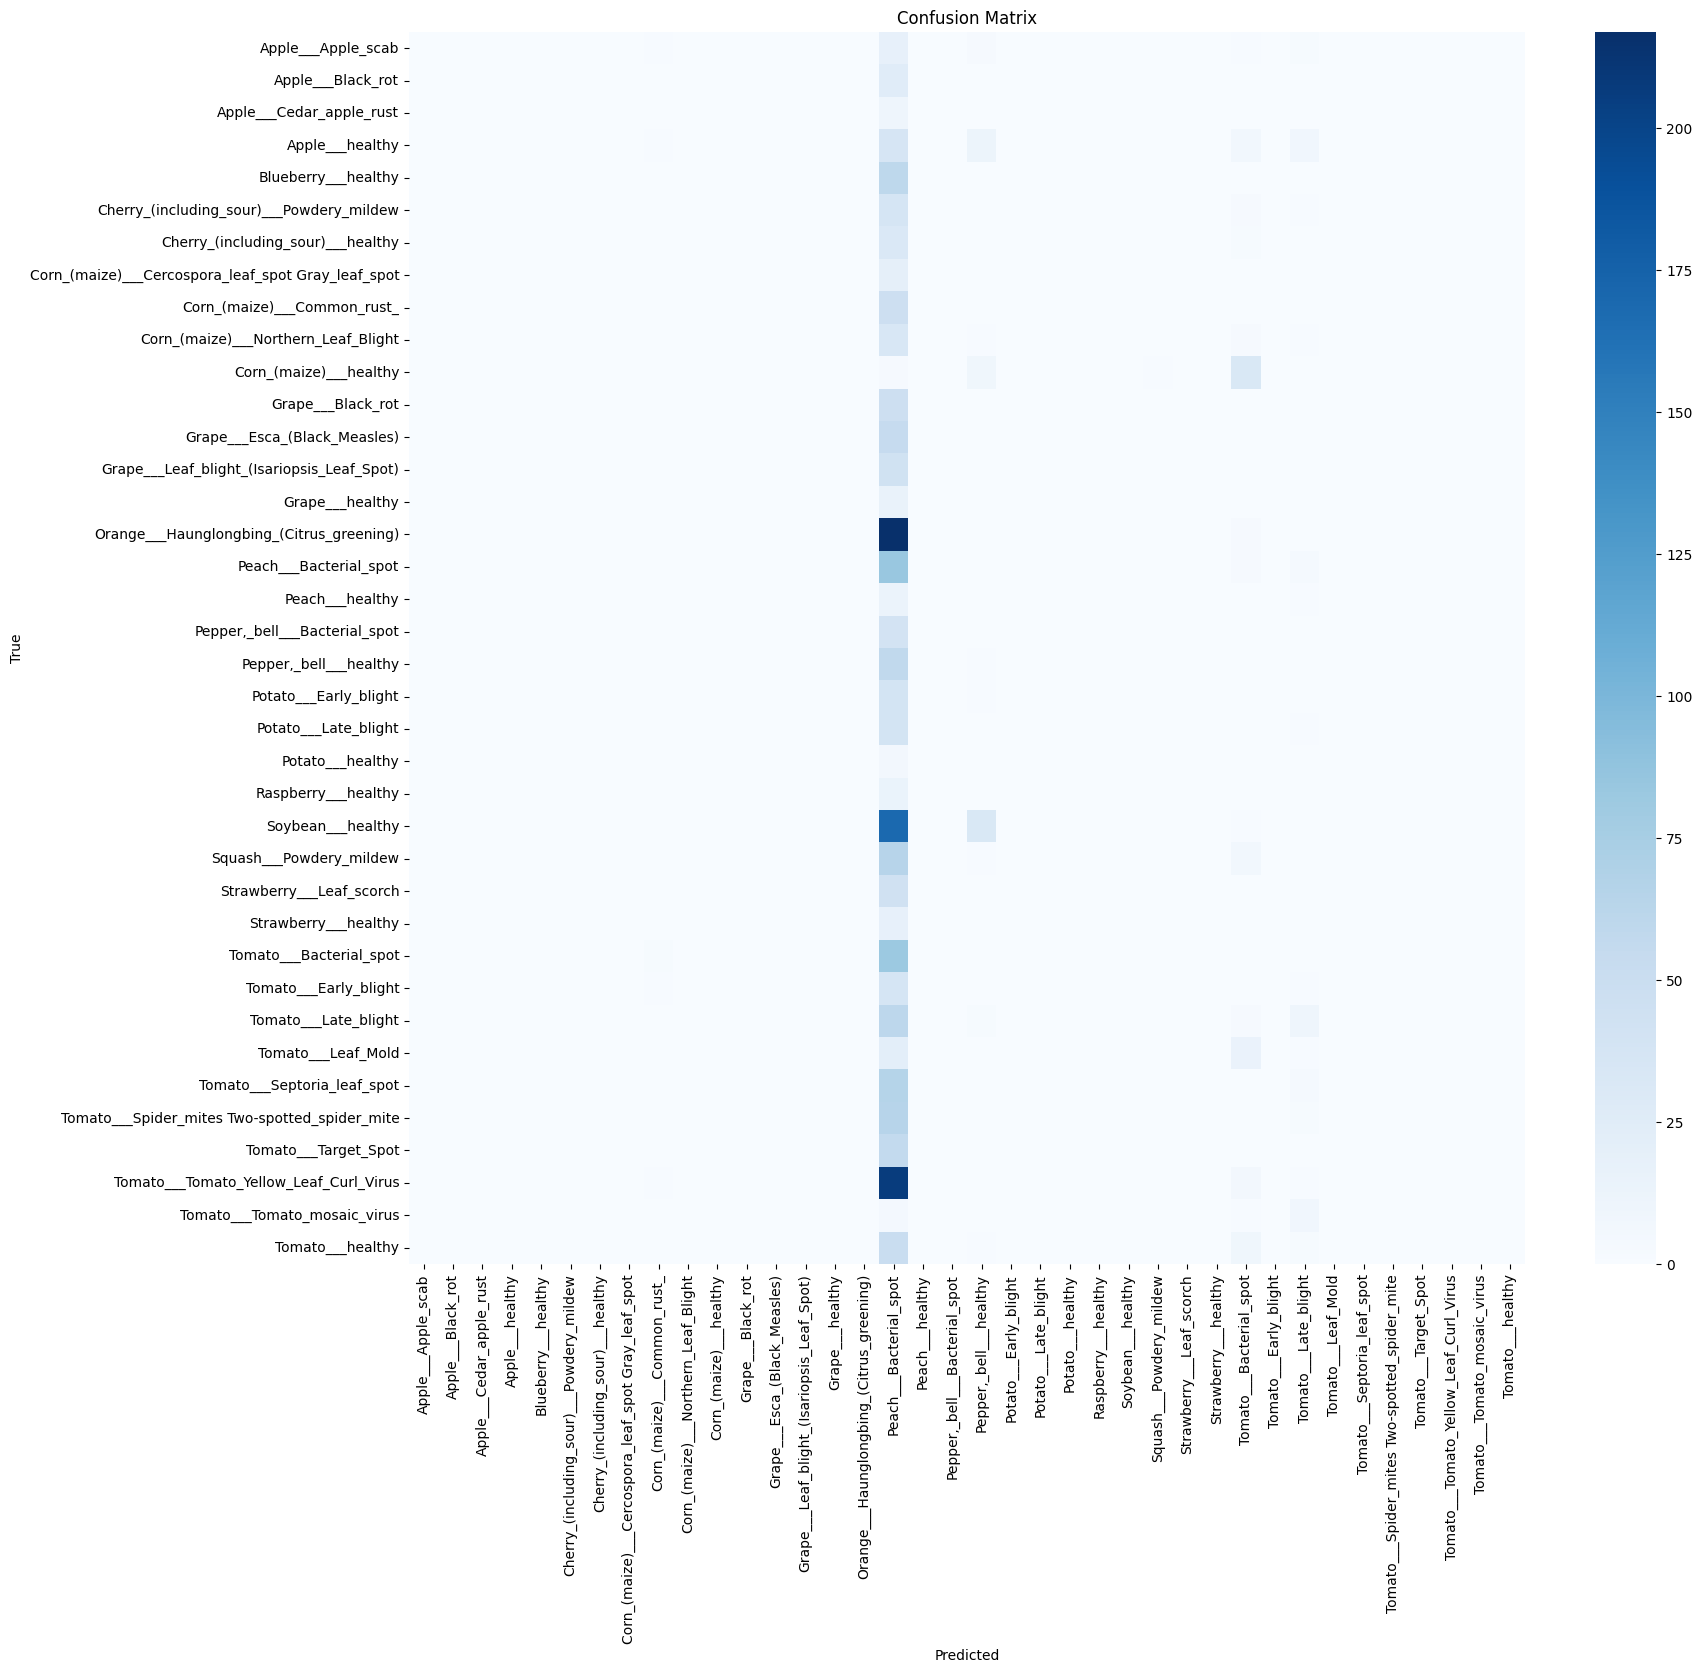

In [152]:
# ==========================================================
# Confusion Matrix
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_true,

    y_pred

)

plt.figure(figsize=(18,16))

sns.heatmap(

    cm,

    cmap="Blues",

    xticklabels=classes,

    yticklabels=classes

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()